# Adversarial Search

In a **competitive environment**, multiple agents have **conflicting goals**, leading to **adversarial search problems**. Games like chess, Go, and poker serve as useful abstractions of real-world challenges. Their structured nature benefits AI research: game states are easily represented, rules and domain knowledge are well-defined, and actions are limited with precise effects. In contrast, real-world problems involve more complex descriptions, a broader action space, and less precise rules. We can approach this problem in three ways. With many agents, we can treat them collectively as an **economy**, predicting trends like rising prices with increased demand without analyzing individual actions. Alternatively, we can consider other agents as part of a **non-deterministic environment**, though this overlooks their intent to act against us, unlike random natural events. Lastly, we can **explicitly model** adversarial agents.

We focus on the third case, and in particular on **deterministic** (or **stochastic**, if chance is involved), **two-player**, **turn-taking**, **perfect information** (fully observable, like chess), **zero-sum** games (one player's gain is the other's loss, with no "win-win" outcomes). Sometimes we can consider **imperfect information game** (e.g. poker) where the players get private information that the other players do not have, and **partially observable game** (e.g. videogames) where each player can see the nearby environment, but not the environment far away.

We refer to the players as **Max** and **Min**, with Max moving first. They alternate turns until the game ends, at which point the winner earns points and the loser receives penalties.

## Two-player, perfect information, zero-sum games

A game is formally defined by:  

- An **initial state** that specifies the starting setup.  
- A function that determines the **current player** in a given state.  
- The **set of legal moves** available in a state.  
- A **transition model** that defines the resulting state after an action.  
- A **terminal test** that indicates whether the game has ended (terminal states).  
- An **utility function** that assigns a numerical value to terminal states.  

Some games, like chess, have discrete outcomes (win, loss, draw), while others, such as backgammon, allow a broader range of payoffs (e.g., 0 to 192). We can impleent a game class in Python to represent the game state and rules:

In [1]:
class Game:

    def actions(self, state):
        # Return a list of the allowable moves at this state
        raise NotImplementedError

    def result(self, state, action):
        # Return the state that results from making a action from a state
        raise NotImplementedError

    def utility(self, state, player):
        # Return the value of this final state to player
        raise NotImplementedError

    def terminal_test(self, state):
        # Return True if this is a final state for the game
        return not self.actions(state)

    def to_move(self, state):
        # Return the player whose move it is in this state
        return state.to_move

    def display(self, state):
        # Display the game state
        print(state)

A game state encapsulates the board configuration, the active player's turn, the evaluated utility of that state, and the list of legal moves available:



In [2]:
from collections import namedtuple

GameState = namedtuple('GameState', 'to_move, utility, board, moves')

We can write a function to play a game from an arbitrary number of players:

In [3]:
def play(game, *players, verbose=False):
    state = game.initial
    while True:
        for player in players:
            action = player(game, state)
            state = game.result(state, action)
            if verbose:
                game.display(state)
            if game.terminal_test(state):
                return game.utility(state, game.to_move(game.initial))

### Tic-Tac-Toe

As an example, we can implement the simple Tic-Tac-Toe game, where two players take turns to place their mark on a 3x3 board. The first player to get three of their marks in a row (horizontally, vertically, or diagonally) wins. If the board is full and no player has won, the game is a draw:

In [4]:
class TicTacToe(Game):

    def __init__(self, h=3, v=3, k=3):
        # Number of rows, columns and winning length
        self.h = h
        self.v = v
        self.k = k

        # Moves are a pair of coordinates (x, y) where a player can place their marker
        moves = tuple((x, y) for x in range(1, h + 1)
                 for y in range(1, v + 1))

        # The initial state with board empty and player X to move         
        self.initial = GameState(to_move='X', utility=0, board=tuple(), moves=moves)

    def actions(self, state):
        # Legal moves are any square not yet taken
        return state.moves

    def result(self, state, move):
        # If the move is not legal, return the current state
        if move not in state.moves:
            return state
        
        # Convert the board to dictionary to work with it.
        board = dict(state.board)

        # Place the marker of the player whose turn it is
        board[move] = state.to_move

        # Remove the move from the list of legal moves
        moves = list(state.moves)
        moves.remove(move)

        # create a new state with the new board and the player who's turn it is
        return GameState(to_move=('O' if state.to_move == 'X' else 'X'),
                         utility=self.compute_utility(board, move, state.to_move),
                         board=tuple(sorted(board.items())), 
                         moves=tuple(moves))

    def utility(self, state, player):
        # Return the utility for player MAX and the negative utility for player MIN 
        return state.utility if player == 'X' else -state.utility

    def terminal_test(self, state):
        # A state is terminal if it is won or there are no empty squares
        return state.utility != 0 or len(state.moves) == 0

    def display(self, state):
        board = dict(state.board)
        for x in range(1, self.h + 1):
            for y in range(1, self.v + 1):
                print(board.get((x, y), '.'), end=' ')
            print()
        print()

    def compute_utility(self, board, move, player):

        # Directions to check for a win (horizontal, vertical, diagonals)
        deltas = [(0, 1), (1, 0), (1, -1), (1, 1)]

        # Coordinates of the move
        x, y = move

        # Iterate through each direction
        for delta_x, delta_y in deltas:

            # Initialize the count of consecutive player marks
            n = 0

            # Check in both directions along the line
            for direction in [1, -1]:

                # Start checking from the move's coordinates
                cx, cy = x, y

                # While the current cell belongs to the player
                while board.get((cx, cy)) == player:
                    # Increment the count
                    n += 1
                    # Move to the next cell in the direction
                    cx, cy = cx + direction * delta_x, cy + direction * delta_y

            # If the count of consecutive marks 
            # (minus the move itself, counted twice) is at least k        
            if n - 1 >= self.k:
                # Return 1 for 'MAX' win, -1 for 'MIN' win
                return 1 if player == 'X' else -1
                
        # No win found, return 0
        return 0

The simple type of agent is a **random player**, which can serve as a **baseline agent** that provides valuable insights into the effectiveness and efficiency of more advanced algorithms. A random player is an agent that selects its moves entirely by chance from the set of available actions, without considering the game state or attempting to maximize its chances of winning:

In [5]:
import random

def random_player(game, state):
    return random.choice(game.actions(state))

We can see a game between two random players:

In [6]:
# Create a TicTacToe game instance
tictactoe = TicTacToe(h=3, v=3, k=3)

# Play the game
play(tictactoe, random_player, random_player, verbose=True);  

. . . 
. . . 
. . X 

. O . 
. . . 
. . X 

. O . 
. . . 
X . X 

. O . 
. . O 
X . X 

. O . 
. . O 
X X X 



We can write a method to conduct experiments between two agents, and collect statistics on the number of wins, losses, and draws:

In [7]:
def run_experiment(game, max, min, num_games=1000):

    # Track wins for X, wins for O, and draws
    outcomes = {'win_max': 0, 'win_min': 0, 'draw': 0}  

    # Play the games    
    for _ in range(num_games):

        # Play a game with the two players
        result = play(game, max, min)  
        
        # Update the outcomes
        if result == 1:
            outcomes['win_max'] += 1
        elif result == -1:
            outcomes['win_min'] += 1
        else:
            outcomes['draw'] += 1

    # Calculate proportions
    total_games = num_games
    win_max_prop = outcomes['win_max'] / total_games
    win_min_prop = outcomes['win_min'] / total_games
    draw_prop = outcomes['draw'] / total_games

    return win_max_prop, win_min_prop, draw_prop

Let's run some experiments between two random players:

In [8]:
# Create a TicTacToe game instance
tictactoe = TicTacToe(h=3, v=3, k=3)

# Run the experiment
win_max_prop, win_min_prop, draw_prop = run_experiment(tictactoe, random_player, random_player, num_games=10000)

# Print the results
print(f"Proportion of Wins for MAX Random player: {win_max_prop:.4f}")
print(f"Proportion of Wins for MIN Random player: {win_min_prop:.4f}")
print(f"Proportion of Draws: {draw_prop:.4f}")

Proportion of Wins for MAX Random player: 0.5821
Proportion of Wins for MIN Random player: 0.2835
Proportion of Draws: 0.1344


The results indicate that the first player has a significant advantage in Tic-Tac-Toe, with a higher win rate (58.3%) compared to the second player (28.8%), and a relatively low draw rate (12.9%). This is counterintuitive, as the game should outcome in a draw with perfect play. The discrepancy is due to the random nature of the agents, which do not play optimally.

### State space graph

In order to represent the game, as in standard search problems, we can use a **state space graph**, where states are vertices, actions are edges, and multiple paths may lead to the same state. A **search tree** overlays part of this graph to determine the best move. The **game tree** is the full search tree that explores all possible move sequences up to terminal states. If the state space is unbounded or allows infinite repetitions, the game tree may be infinite. The following figure shows a portion of the game tree for tic-tac-toe:

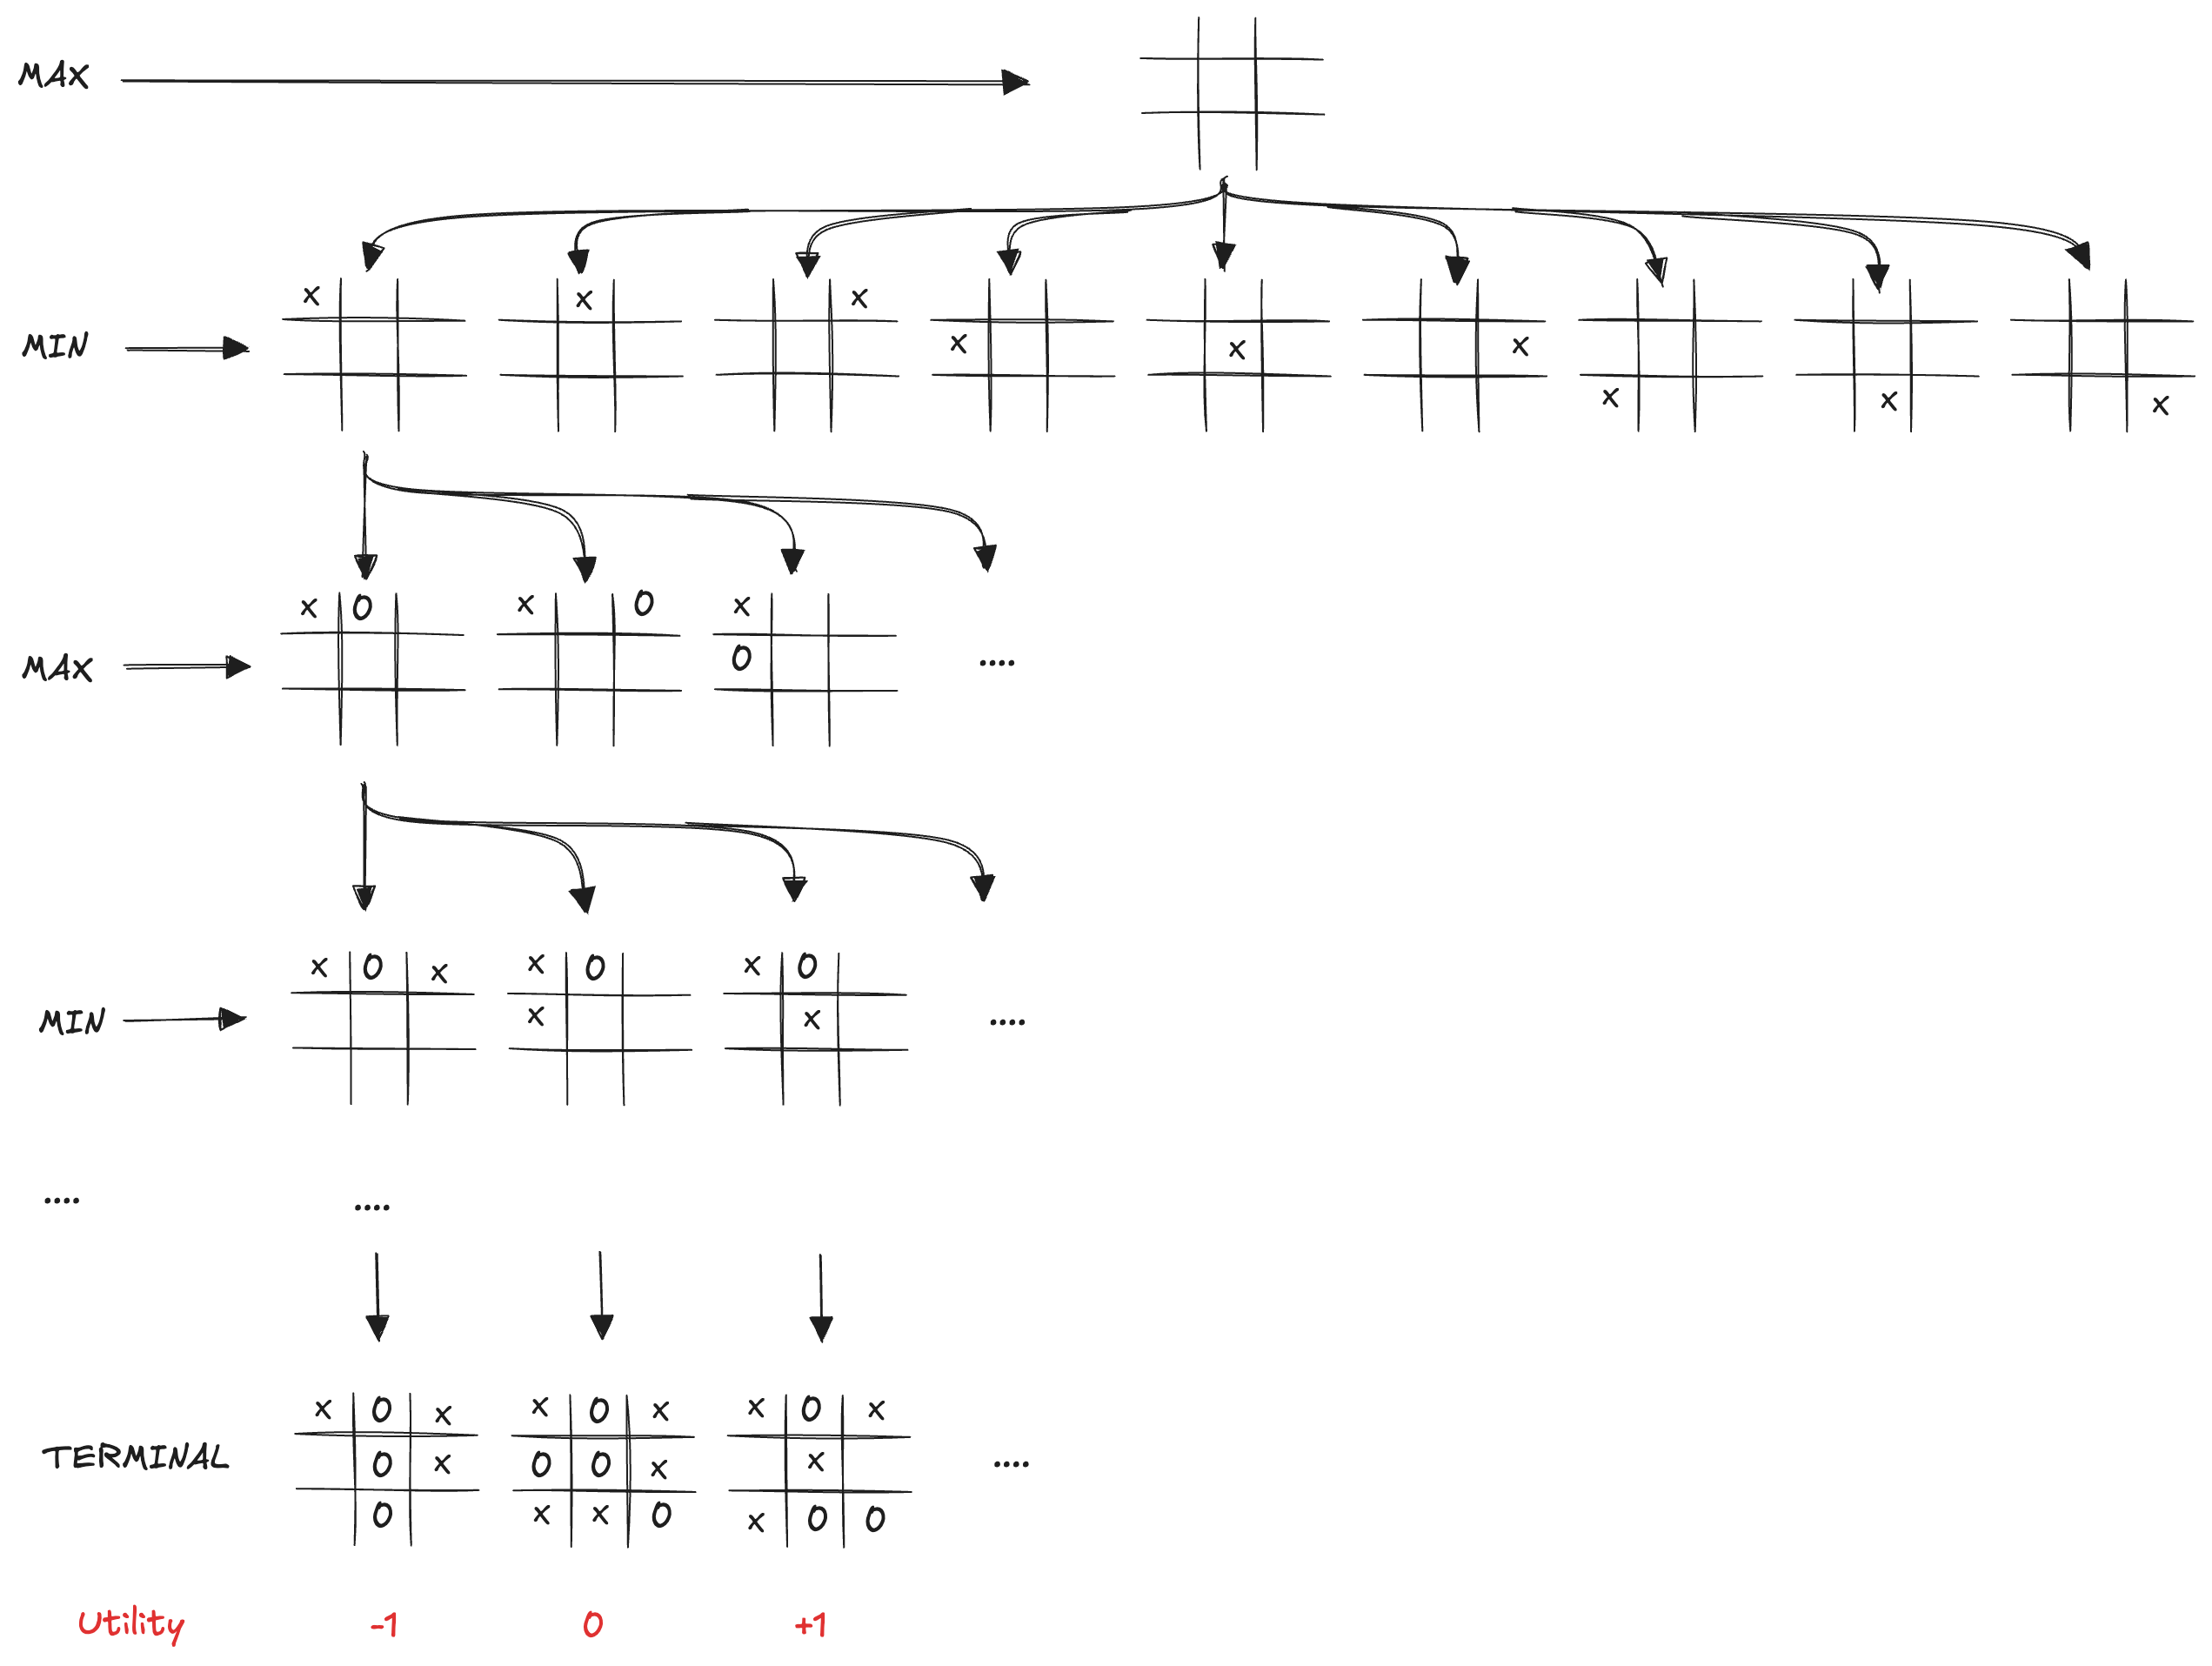

From the initial state, MAX has nine possible moves. Players alternate turns, with MAX placing X and MIN placing O, until reaching a terminal state where a player wins or the board is full. Each terminal state's utility value reflects MAX perspective (higher values favor MAX, lower ones favor MIN). We can implement a function to create an entire graph for a  game:


In [9]:
def create_state_space_graph(game):
    graph = {}
    initial_state = game.initial
    queue = [initial_state]
    visited = {initial_state}

    while queue:
        current_state = queue.pop(0)
        graph[current_state] = {}

        if game.terminal_test(current_state):
            continue

        for action in game.actions(current_state):
            next_state = game.result(current_state, action)
            graph[current_state][action] = next_state

            if next_state not in visited:
                visited.add(next_state)
                queue.append(next_state)

    return graph

We can create the graph for Tic-Tac-Toe in order to count the number of states:

In [10]:
state_space = create_state_space_graph(tictactoe)
print(f"Number of states: {len(state_space)}")

Number of states: 5478


Tic-tac-toe is small, with only 5.478 distinct states and the game tree can be fully explored with 9!=362.880 terminal nodes. In contrast, chess has over 10^40 nodes, making the possibility to create a game tree **purely theoretical** and **impossible to fully compute**. 

## Optimal decisions

MAX seeks a winning sequence, but MIN actively counters it. Thus, MAX’s strategy must be a **conditional plan**, responding to each of MIN’s moves to guarantee the best outcome **regardless** of MIN actions. In general, there is no sequence of actions that makes a player win independently of the actions of the opponent.

### Minimax

The optimal strategy can be found by computing the **minimax value** of each state, representing the utility **assuming both players play optimally**. Terminal states take their utility as the minimax value. In non-terminal states, MAX chooses the highest-value move, while MIN selects the lowest (which is best for MIN but worst for MAX). Thus, we have:

$\displaystyle \text{minimax}( s) = \begin{cases} \text{utility}( s) & \text{if } \text{is-terminal}( s) \\ \max_{a} \text{minimax}( \text{result}( s, a)) & \text{if } \text{player}( s) = \text{MAX} \\ \min_{a} \text{minimax}( \text{result}( s, a)) & \text{if } \text{player}( s) = \text{MIN} \end{cases}$

Consider the following trivial game:

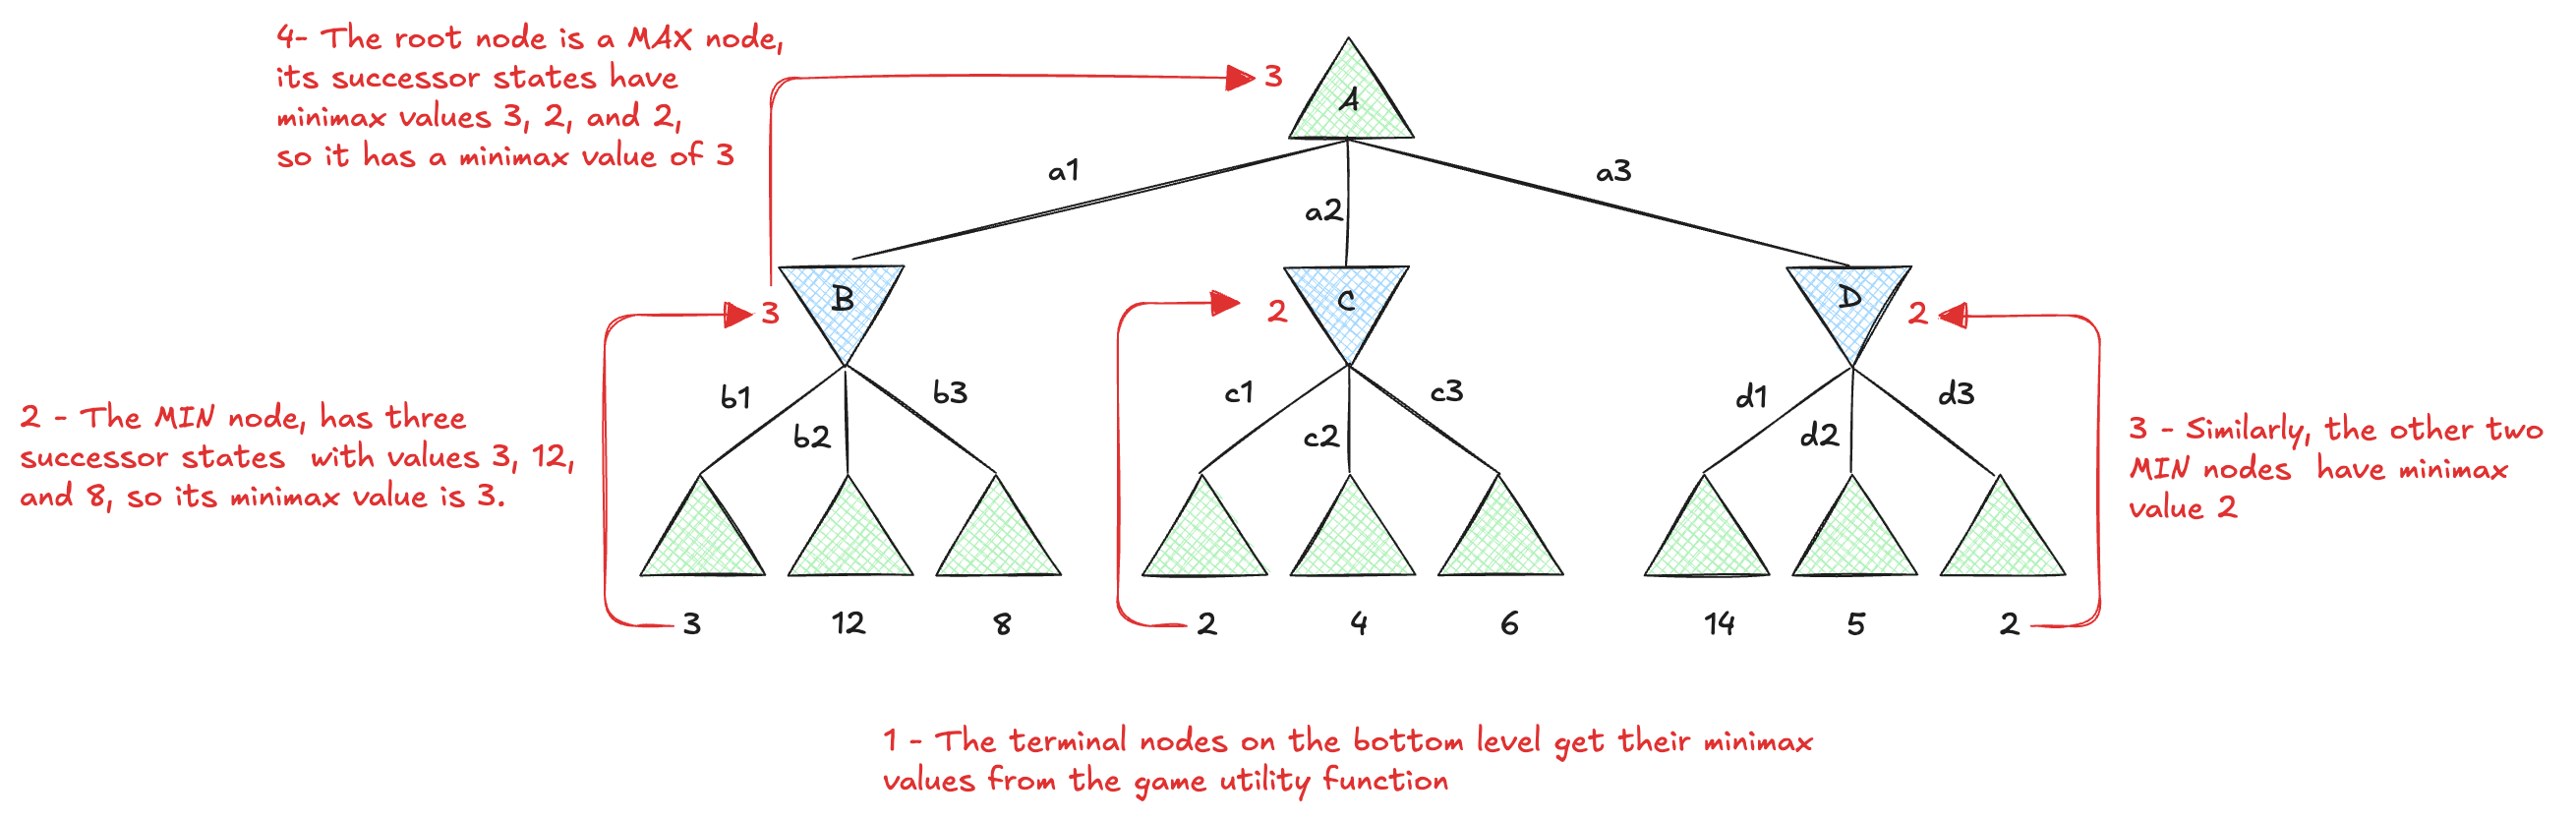

By propagating **minimax values** from terminal states to the root, we determine the **minimax decision**: in this example, MAX should choose a1, as it leads to the highest minimax value. This definition of optimal play for MAX assumes that MIN also plays optimally. If MIN plays suboptimally, MAX will do at least as well, possibly better. However, playing the minimax-optimal move isn’t always best against a weaker opponent. For instance, if perfect play leads to a draw, but a **risky move** gives MIN multiple reasonable responses, most leading to a loss but one to a win, MAX might want to try the risky move, betting on MIN limited ability, on the grounds that a lot of chance of a win is better than a certain draw. First, we can implement a recursive function to compute the minimax value for all states in the tree, starting from a given state (e.g. the initial state):

In [11]:
import numpy as np

def minimax(game, state, MAX='X', MIN='O'):

    # A dictionary to hold the minimax values of states
    minimax_values = {}

    # Determine which player is to move
    player = game.to_move(state)

    # A function to return the maximum utility value of a state for the maximizing player
    def max_value(state):

        # If state has already been evaluated, return its value
        if state in minimax_values:
            return minimax_values[state]

        # If game is over, return its utility
        if game.terminal_test(state):
            result = game.utility(state, player)
            minimax_values[state] = result
            return result

        # Otherwise, initialize value to negative infinity
        v = -np.inf
        
        # Iterate over all possible actions
        for a in game.actions(state):
            # Compute the best achievable value
            # considering the opponent plays optimally
            v = max(v, min_value(game.result(state, a)))

        # Return the best achievable value
        minimax_values[state] = v
        return v

    # A function to return the minimum utility value of a state for the maximizing player
    def min_value(state):

        # If state has already been evaluated, return its value
        if state in minimax_values:
            return minimax_values[state]

        # If game is over, return its utility
        if game.terminal_test(state):
            result = game.utility(state, player)
            minimax_values[state] = result
            return result

        # Otherwise, initialize value to positive infinity    
        v = np.inf

        # Iterate over all possible actions
        for a in game.actions(state):
            # Compute the best achievable value
            # considering the opponent plays optimally
            v = min(v, max_value(game.result(state, a)))
        
        # Return the best achievable value
        minimax_values[state] = v
        return v
    
    # Start the minimax recursion from the given state
    # taking into account whether the player is maximizing or minimizing
    if player == MAX:
        max_value(state)
    else:
        min_value(state)
    
    # Return the dictionary of minimax values
    return minimax_values

Now that we can compute the minimax, we can turn that into a search algorithm that finds the best move for the player by trying all actions and choosing the one whose resulting state has the highest value:

In [12]:
def minimax_player(game, state, MAX='X', MIN='O'):

    # If the game is over, return None
    if game.terminal_test(state):
        return None

    # The minimax tree, it wis built from the perspective of MAX.
    # So for MAX turn, we need to choose the move that maximizes the value
    # and for MIN turn, we need to choose the move that minimizes that value

    # If the player is MAX, return the action with the highest minimax value
    if state.to_move == MAX:
        # Initialize the best action and value
        best_action = None
        best_value = -float('inf')  

        # Iterate over all possible actions
        for action in game.actions(state):

            # Compute the value of the state resulting from the action
            next_state = game.result(state, action)

            # Get the minimax value of the state
            action_value = minimax_values.get(next_state, -float('inf')) #get value.

            # Update the best action and value
            if action_value > best_value:
                best_value = action_value
                best_action = action

    # If the player is MIN, return the action with the lowest minimax value
    else:
         # Initialize the best action and value
        best_action = None
        best_value = float('inf')  

        # Iterate over all possible actions
        for action in game.actions(state):

            # Compute the value of the state resulting from the action
            next_state = game.result(state, action)

            # Get the minimax value of the state
            action_value = minimax_values.get(next_state, -float('inf')) #get value.

            # Update the best action and value
            if action_value < best_value:
                best_value = action_value
                best_action = action
    
    # Return the best action
    return best_action


Let's test the minimax algorithm in Tic-Tac-Toe against a random player:

In [13]:
# Create a new TicTacToe game
tictactoe = TicTacToe(h=3, v=3, k=3)

# Build the tree
minimax_values = minimax(tictactoe, tictactoe.initial)  

# Run the experiment
win_max_prop, win_min_prop, draw_prop = run_experiment(tictactoe, minimax_player, random_player, num_games=10000)

# Print the results:
print(f"Proportion of Wins for MAX Minimax player: {win_max_prop:.4f}")
print(f"Proportion of Wins for MIN Random player: {win_min_prop:.4f}")
print(f"Proportion of Draws: {draw_prop:.4f}")

Proportion of Wins for MAX Minimax player: 0.9948
Proportion of Wins for MIN Random player: 0.0000
Proportion of Draws: 0.0052


The results show that the second player never wins, which is expected since, in Tic-Tac-Toe, a perfectly rational first player can always avoid losing. However, we do observe a certain percentage of draws. These occur when the random player, by chance, makes rational moves and leads the game to a tie. To determine whether this percentage is reasonable, we can formally analyze the probability of the second player randomly selecting the correct moves:

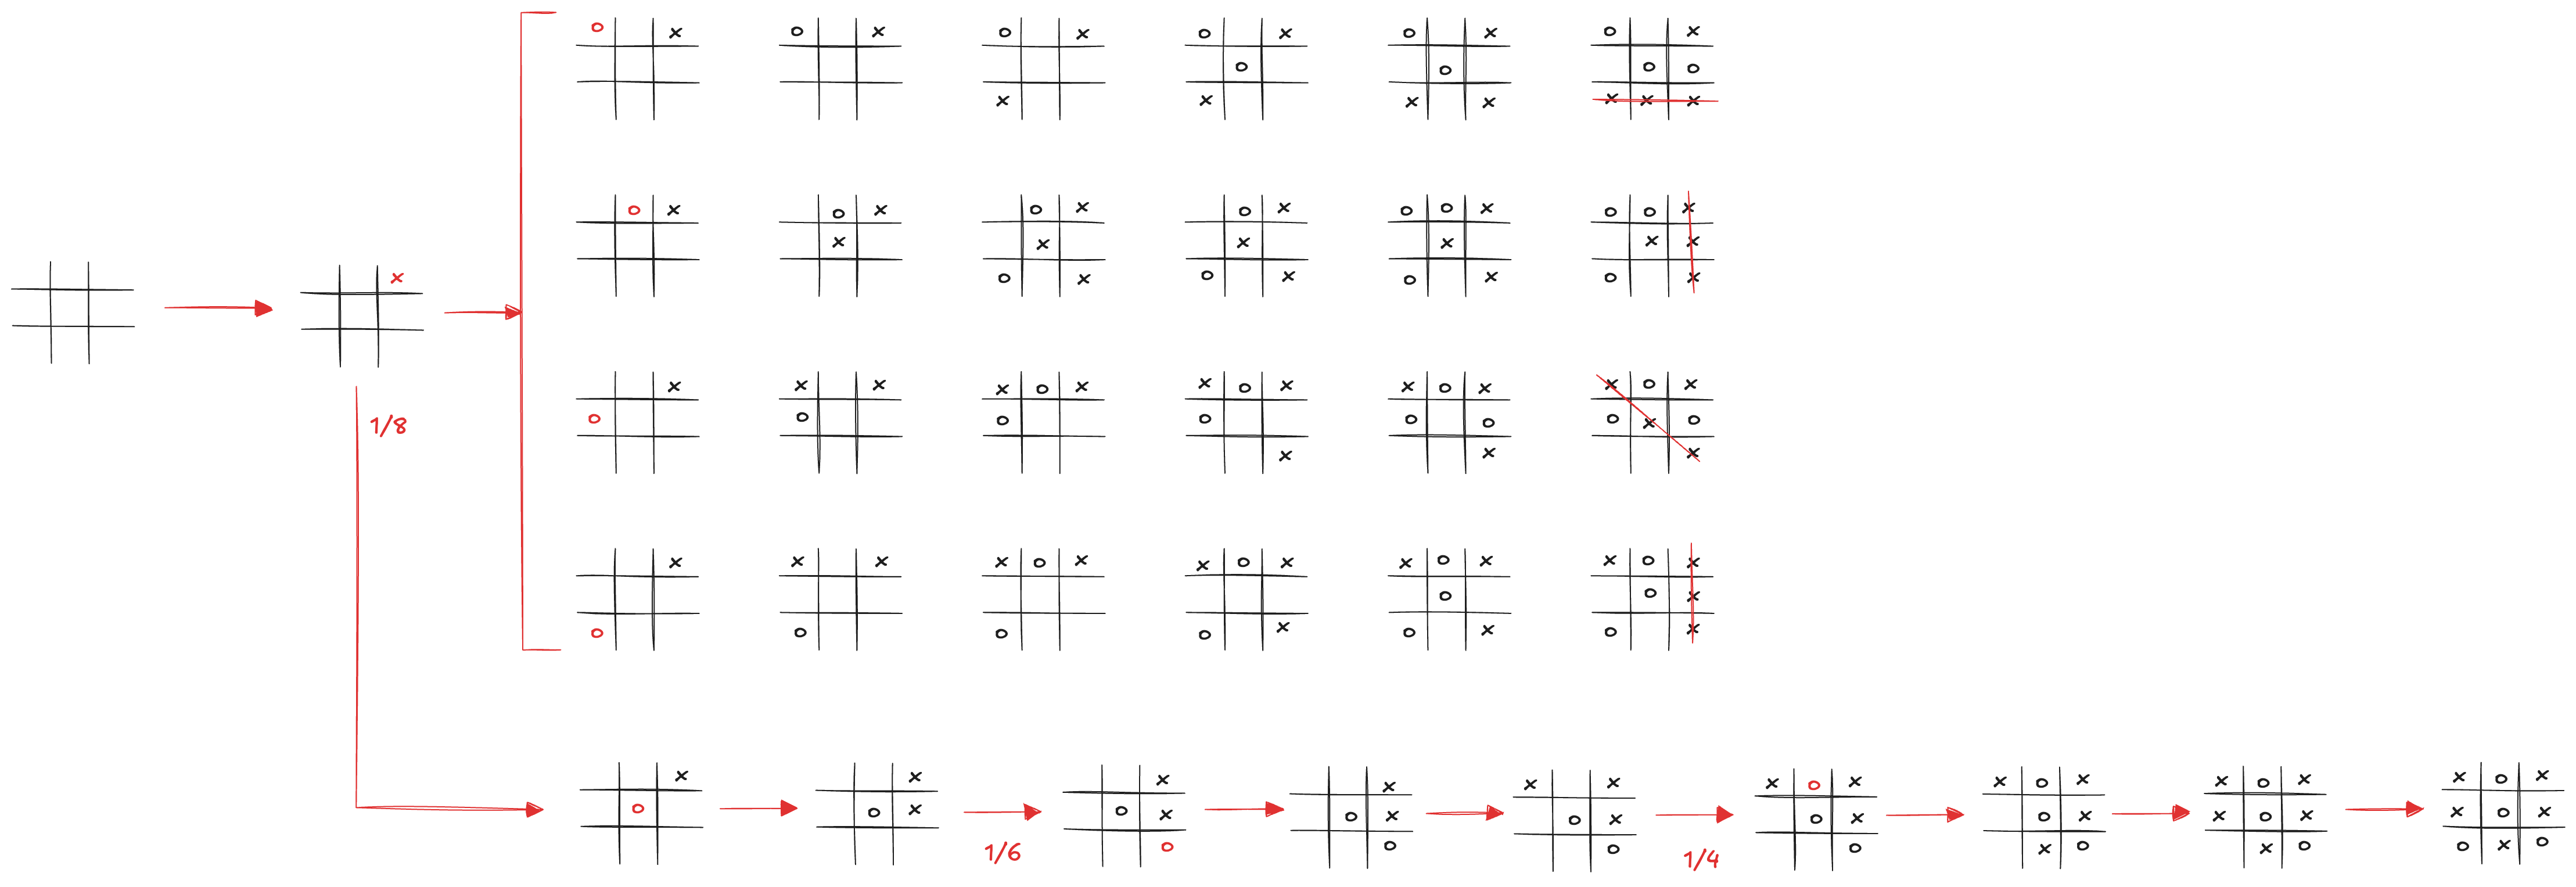

So, the second random player has a probability of drawing of:

$\displaystyle \frac{1}{8} \times \frac{1}{6} \times \frac{1}{4} \approx 0.005$

which is coherent with the observed results from the simulation. We can experiment also the performance of the minimax player when it plays as the second player against a random player:

In [14]:
# Create a new TicTacToe game
tictactoe = TicTacToe(h=3, v=3, k=3)

# Build the tree
minimax_values = minimax(tictactoe, tictactoe.initial)  

# Run the experiment
win_max_prop, win_min_prop, draw_prop = run_experiment(tictactoe, random_player, minimax_player, num_games=10000)

# Print the results:
print(f"Proportion of Wins for MAX Minimax player: {win_max_prop:.4f}")
print(f"Proportion of Wins for MIN Random player: {win_min_prop:.4f}")
print(f"Proportion of Draws: {draw_prop:.4f}")

Proportion of Wins for MAX Minimax player: 0.0000
Proportion of Wins for MIN Random player: 0.8082
Proportion of Draws: 0.1918


Since the first player has some advantage, the random player has some more chances to draw when it plays first. The minimax algorithm performs a complete depth-first exploration of the game tree. If the maximum depth of the tree is m and there are b legal moves at each point, then the time complexity of the minimax algorithm is:

$\displaystyle O( b^{m})$

and the space complexity is 

$\displaystyle O(bm)$

The exponential complexity makes Minimaz **impractical for complex games**. For example, chess has a branching factor of about 35 and the average game has depth of about 80, and it is not feasible to search 

$\displaystyle 35^{80} \approx 10^{123}$

states. It does, however, serve as **a basis** for the mathematical analysis of games. By approximating the minimax analysis in various ways, we can derive more practical algorithms.

### Alpha–Beta Pruning

The number of game states is exponential in the depth of the tree. No algorithm can completely eliminate the exponent, but we can sometimes cut it in half, computing the correct minimax decision without examining every state by **pruning** large parts of the tree that make no difference to the outcome. Consider again the simple game tree: 

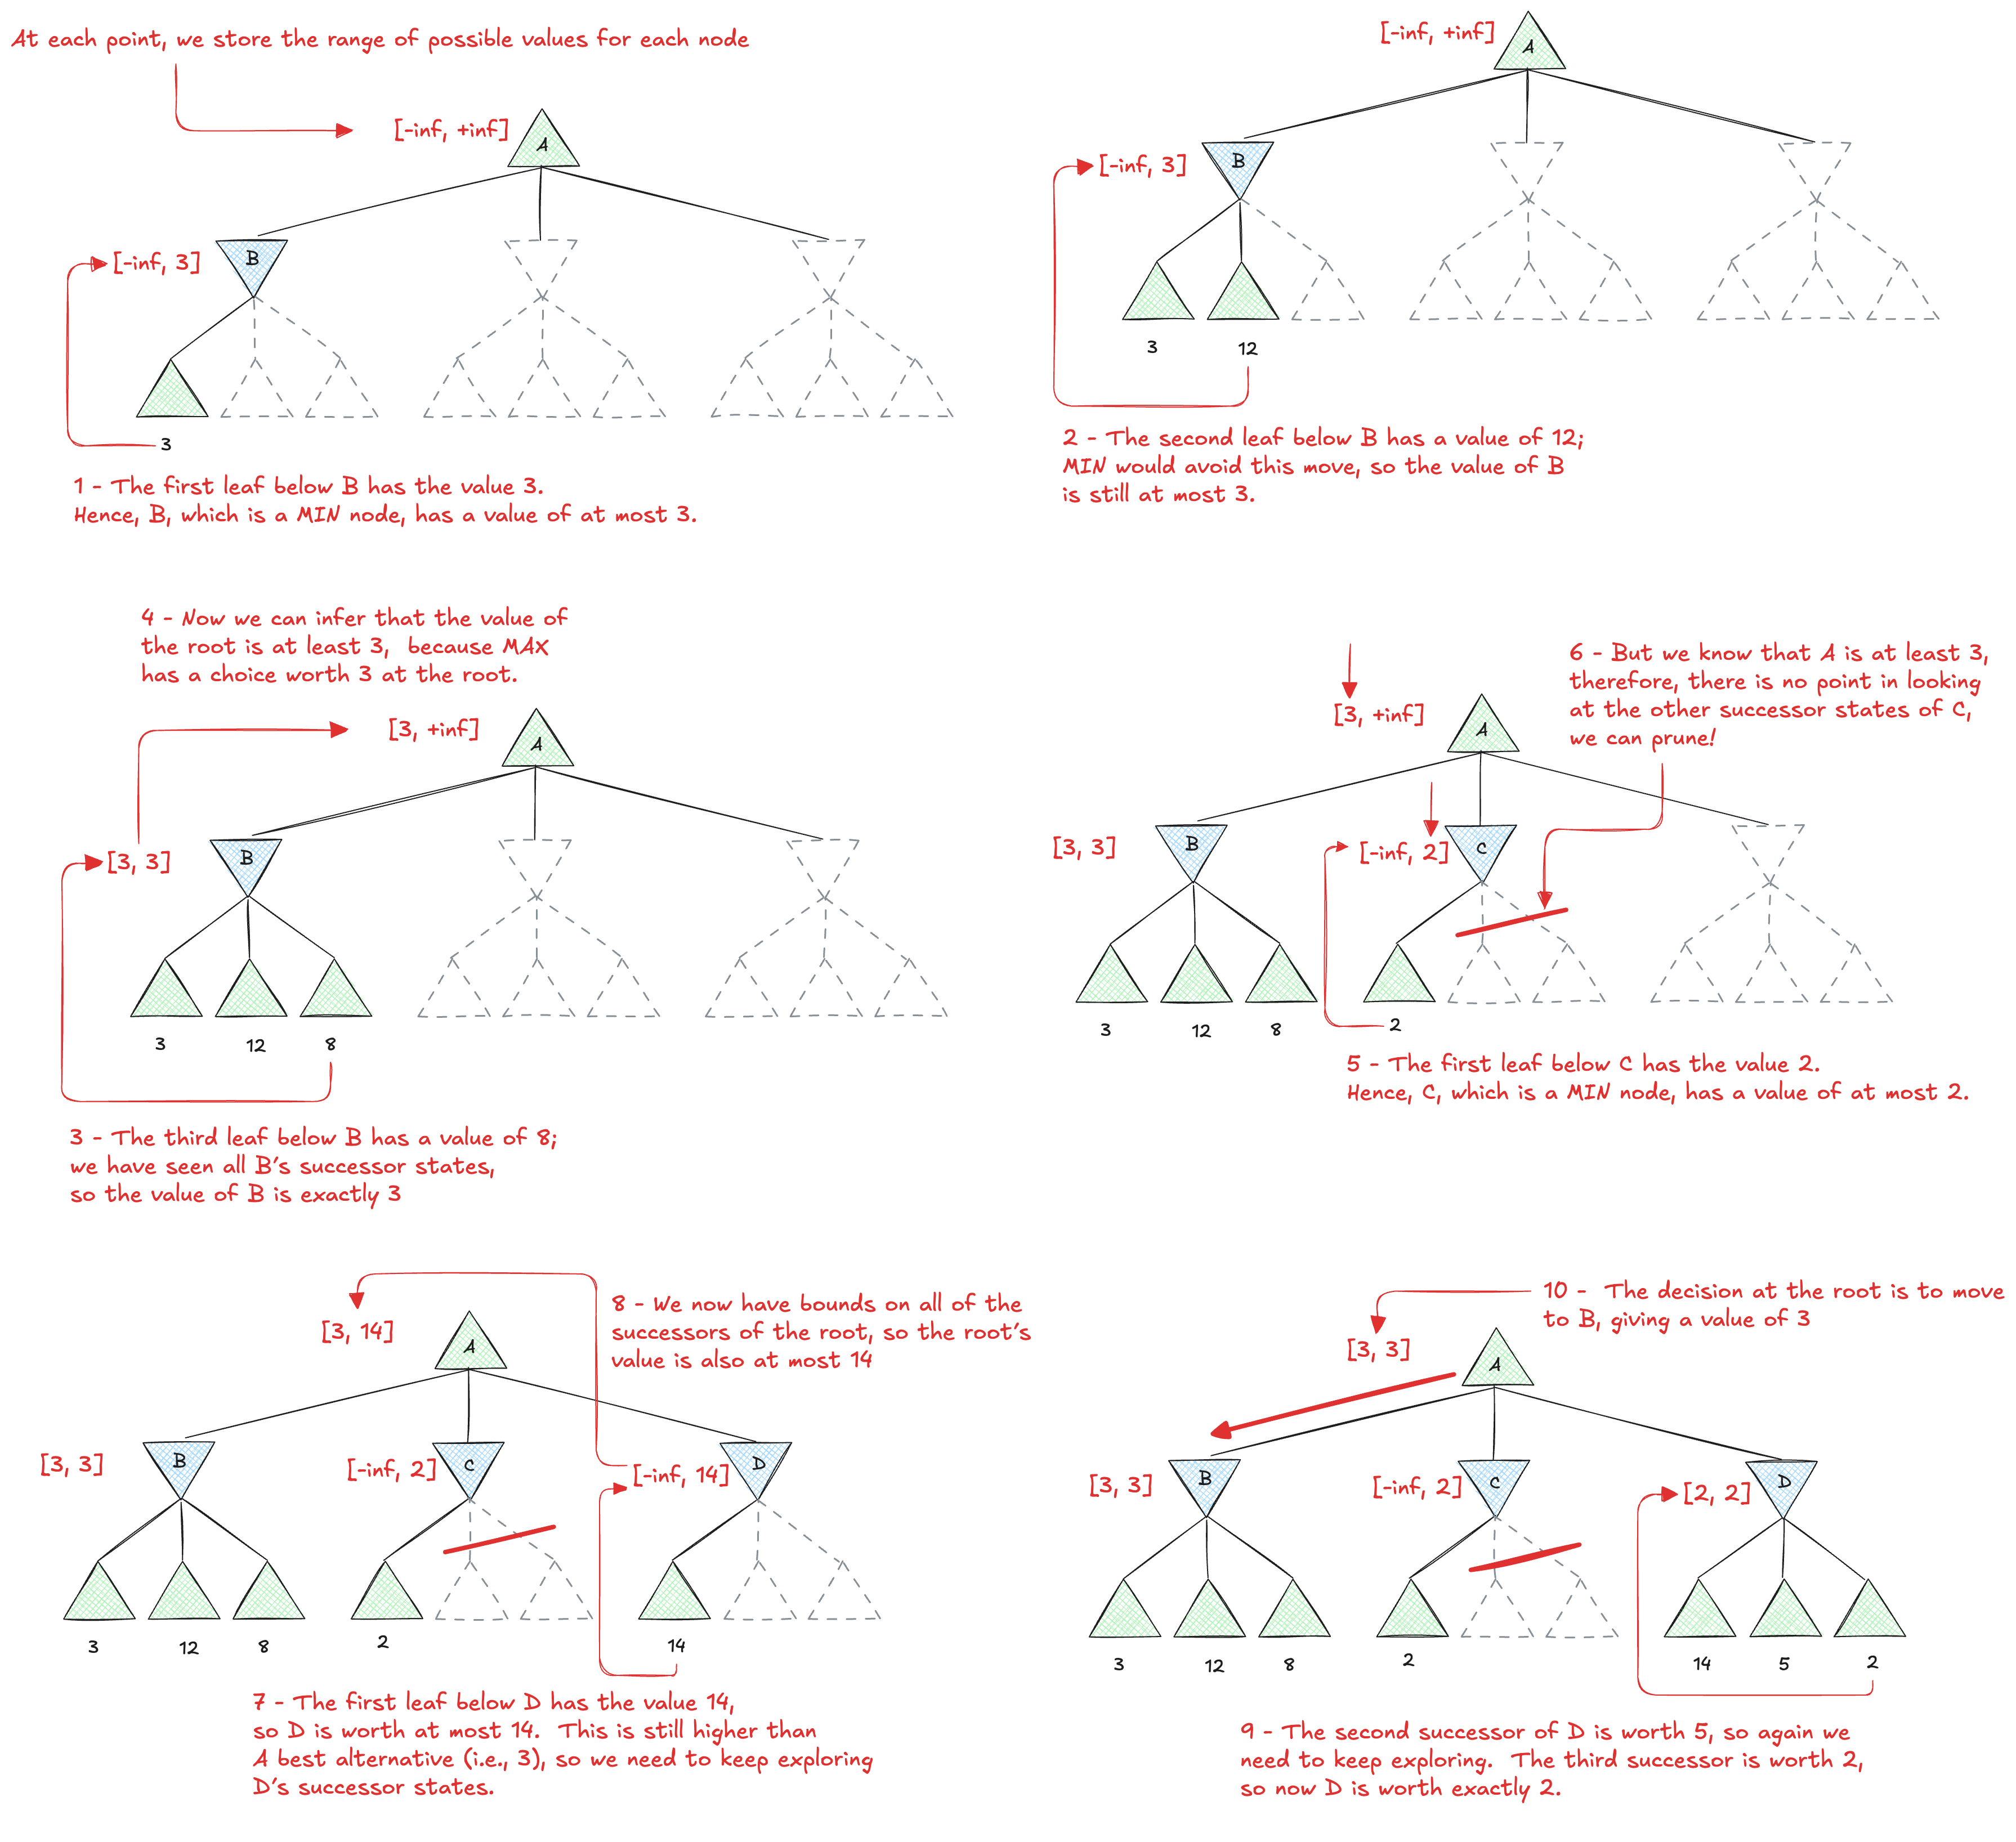

We can express this observation matematicaly:

$\displaystyle \text{Minimax(A)} = \text{max}(\text{min(2, 12, 8)}, \text{min(2, x, y)}, \text{min}(14,5,2)) =$

$\displaystyle = \text{max}(3, \text{min}(2, x, y), 2) = 3$

$\displaystyle = \text{max}(3, < 2, 2) = 3$

In that case, we can identify the minimax decision without ever evaluating some nodes, since the value of A and hence the minimax decision are independent of the values of the leaves x and y of B, and therefore they can be pruned. **Alpha–beta pruning** works at any tree depth and **often prunes entire subtrees**, not just leaves. The key idea is if a player has a clearly better move available, he will never choose an inferior option. Once we confirm a branch is irrelevant, we stop exploring it:

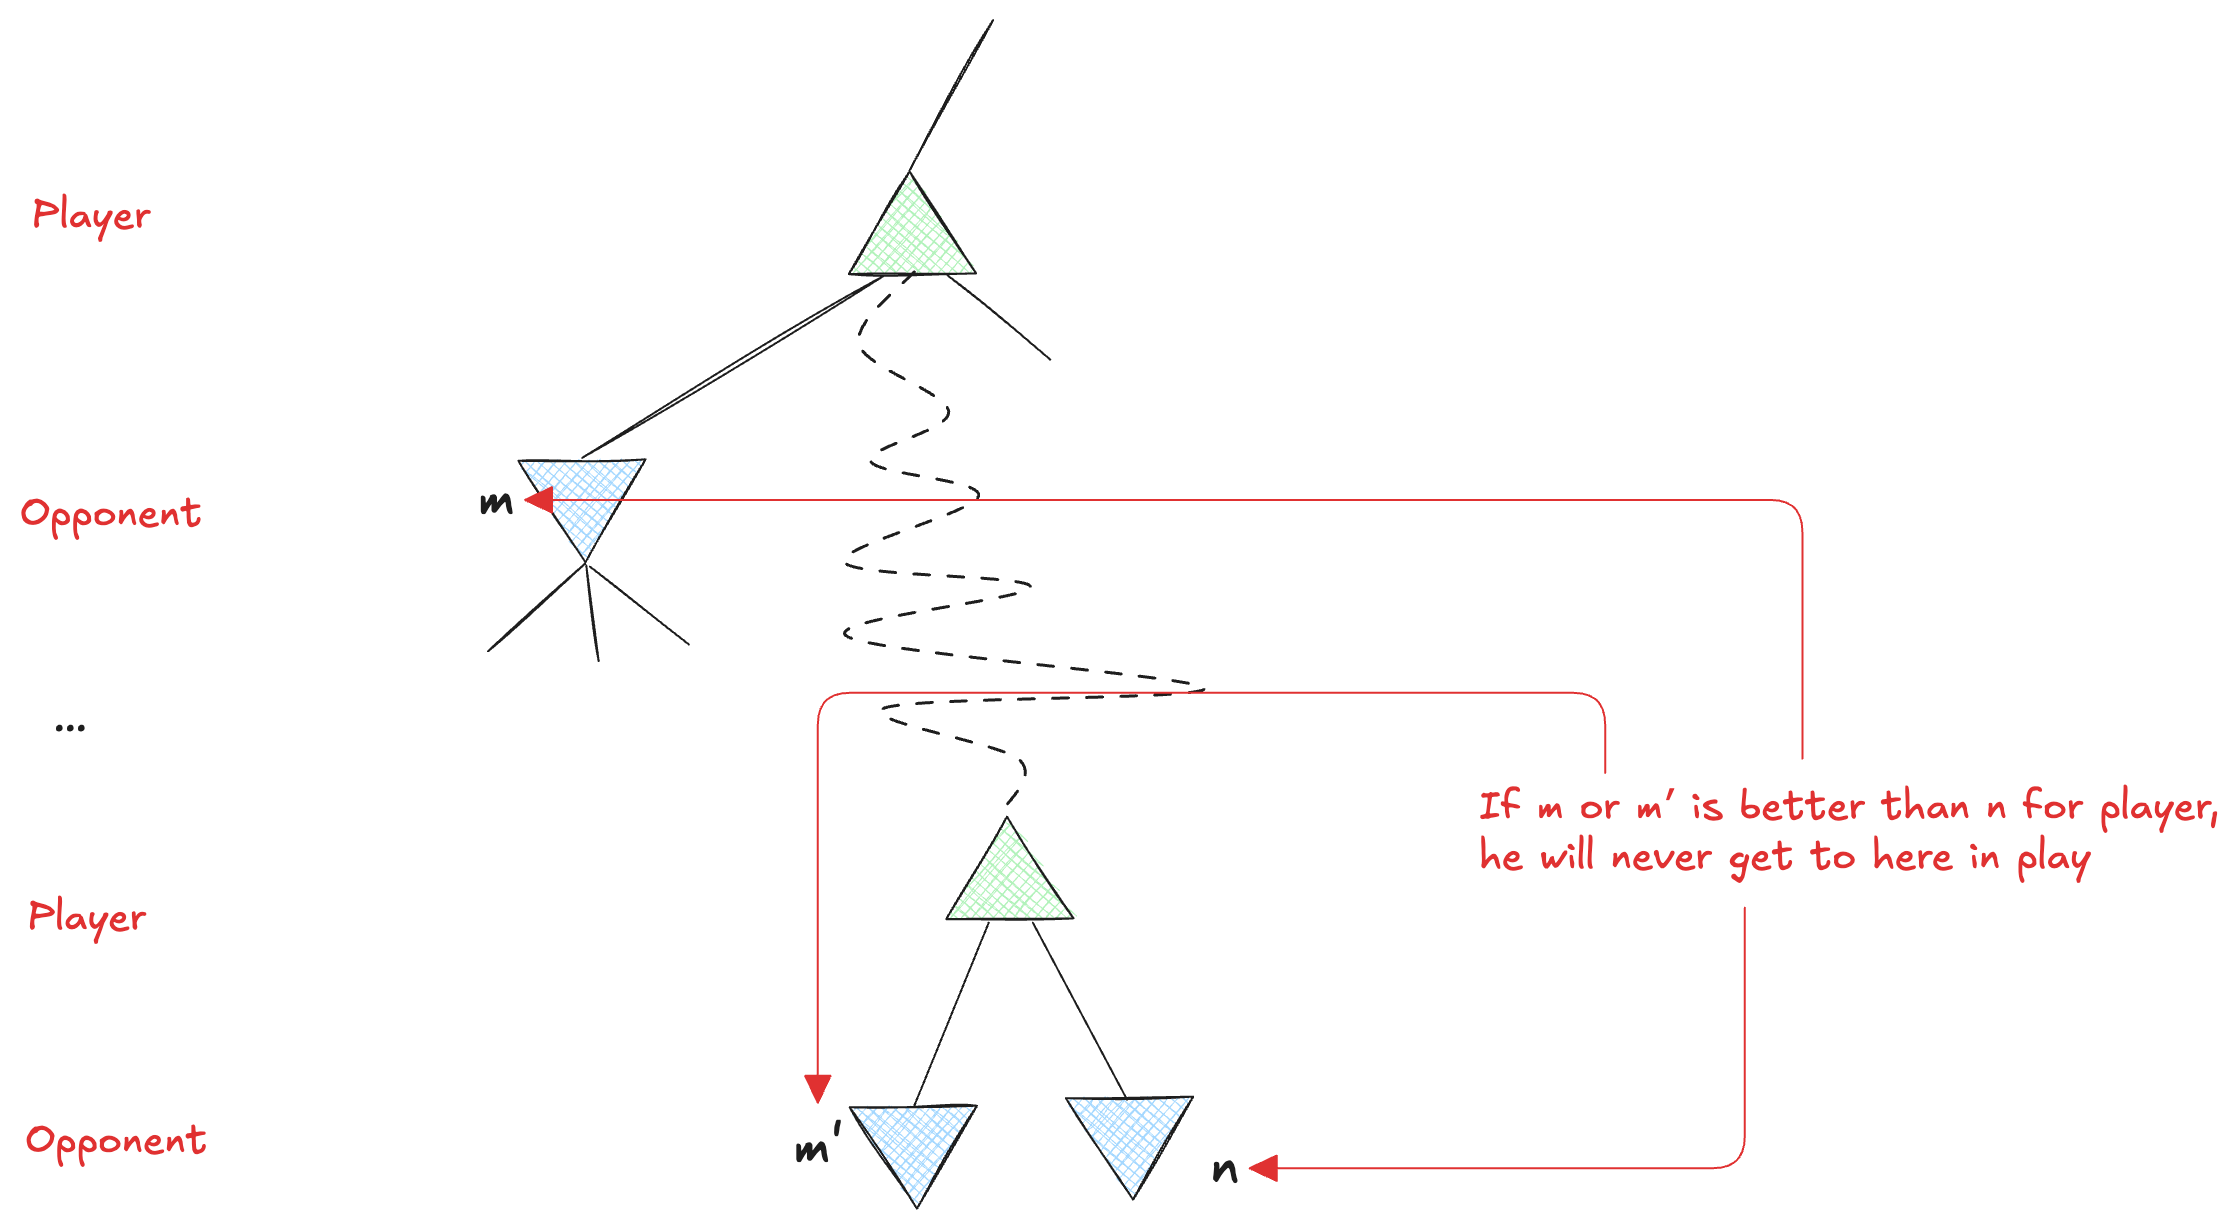

The algorithm maintains two values:

- **alpha** is the value of the best (i.e., highest-value) choice we have found so far at any choice point along the path for MAX
- **beta** is the value of the best (i.e., lowest-value) choice we have found so far at any choice point along the path for MIN

The algorithm updates these values as it goes along and prunes the remaining branches at a node (i.e., terminates the recursive call) as soon as the value of the current node is known to be worse than the current values for MAX or MIN, respectively.

In [15]:
import numpy as np

def pruning_minimax(game, state, MAX='X', MIN='O'):

    # A dictionary to hold the minimax values of states
    minimax_values = {}

     # Determine which player is to move
    player = game.to_move(state)

    # A function to return the maximum utility value of a state for the maximizing player
    def max_value(state, alpha, beta):

        # If state has already been evaluated, return its value
        if state in minimax_values:
            return minimax_values[state]
        
        # If game is over, return its utility
        if game.terminal_test(state):
            result = game.utility(state, player)
            minimax_values[state] = result
            return result

        # Otherwise, initialize value to negative infinity
        v = -np.inf

        # Iterate over all possible actions
        for a in game.actions(state):
            
            # Compute the best achievable value
            # considering the opponent plays optimally
            v = max(v, min_value(game.result(state, a), alpha, beta))
            
            # If v is greater than or equal to beta, 
            # we can prune (return immediately) 
            # because MIN will avoid this branch. 
            if v >= beta:
                minimax_values[state] = v
                return v

            # update alpha    
            alpha = max(alpha, v)
        
        # Return the best achievable value
        minimax_values[state] = v
        return v

    def min_value(state, alpha, beta):

        # If state has already been evaluated, return its value
        if state in minimax_values:
            return minimax_values[state]

        # If game is over, return its utility
        if game.terminal_test(state):
            result = game.utility(state, player)
            minimax_values[state] = result
            return result

        # Otherwise, initialize value to positive infinity 
        v = np.inf

        # Iterate over all possible actions
        for a in game.actions(state):

            # Compute the best achievable value
            # considering the opponent plays optimally
            v = min(v, max_value(game.result(state, a), alpha, beta))

            # If v is less than or equal to alpha, 
            # the branch is pruned since MAX would avoid it
            if v <= alpha:
                minimax_values[state] = v
                return v
            
            # update beta
            beta = min(beta, v)

        # Return the best achievable value
        minimax_values[state] = v
        return v

    # Start the recursion with initial alpha and beta values
    if player == MAX:
        max_value(state, -np.inf, np.inf)
    else:
        min_value(state, -np.inf, np.inf)

    return minimax_values

We can compare the number of nodes considered by the minimax and alpha-beta pruning algorithms:

In [16]:
# Build the tre
minimax_values = minimax(tictactoe, tictactoe.initial)  

# Build the tree using alpha-beta pruning
pruned_minimax_values = pruning_minimax(tictactoe, tictactoe.initial)  

print("Minimax nodes: ", len(minimax_values))
print("Minimax pruned nodes: ", len(pruned_minimax_values))

Minimax nodes:  5478
Minimax pruned nodes:  2592


The effectiveness of alpha–beta pruning is highly dependent on the order in which the states are examined. In the simple example, we could not prune any successors of D at all because the worst successors were generated first. If the third successor of D had been generated first (with value 2), we would have been able to prune the other two successors. This suggests that it might be worthwhile to try to first examine the successors that are likely to be best.
If this could be done perfectly, alpha–beta would need to examine only: 

$\displaystyle O\left(b^{m/2}\right)$

nodes to pick the best move. This mean that we can solve a tree roughly twice as deep as minimax in the same amount of time. With random move ordering, the total number of nodes examined will be roughly:

$\displaystyle O\left(b^{3m/4}\right)$

We cannot achieve perfect ordering, otherwise the ordering function could be used to play a perfect game. However, with several heurstics we can often get fairly close. As a general principle, the **most promising** plays should be expanded first.

## Heuristic-based decisions


In realistic games, we cannot search to leaves since the computation time is limited. In order to overcome this limitation, we can stop the search early and use an **heuristic evaluation function** to **estimate state utility**, treating non-terminal nodes as terminal. This means replacing the utility() function with a new eval() function and the terminal test with a **cutoff test**, which stops the search at terminal states or based on depth and other conditions. This approach defines the **heuristic minimax value** as follows:

$\displaystyle \text{heuristic-minimax}( s) = \begin{cases} \text{eval}( s) & \text{if } \text{cutoff-test}( s) \\ \max_{a} \text{heuristic-minimax}( \text{result}( s, a)) & \text{if } \text{player}( s) = \text{MAX} \\ \min_{a} \text{heuristic-minimax}( \text{result}( s, a)) & \text{if } \text{player}( s) = \text{MIN} \end{cases}$



### Evaluation function

An heuristic evaluation function **estimates a state expected utility**. For terminal states, it matches utility(), while for non-terminal states, it should produce values within the range from loss to win, in order to ensures consistency with the actual outcome and avoids unrealistic evaluations:

$\displaystyle \text{utility}(\text{loss}, p) \leq \text{eval}(s, p) \leq \text{utility}(\text{win}, p)$

A good evaluation function should be **fast to compute** (since the goal is faster search) and **strongly correlated with actual winning chances**. While games like chess have deterministic outcomes with perfect play, cutting off the search at non-terminal states **introduces uncertainty**. An evaluation function can be built by extracting **features**, quantifiable aspects of a state (e.g., in chess, the number of pawns, knights, queens, or strategic factors like pawn structure and king safety). Each feature contributes a weighted value, and their sum determines the final evaluation. The weights should be normalized so that the sum is always within the range. This approach, used by chess players for centuries, forms a **weighted linear function**:

$\displaystyle \text{eval}( s) = w_{1} f_{1}( s) + w_{2} f_{2}( s) + \ldots + w_{n} f_{n}( s) = \sum_{i=1}^{n} w_{i} f_{i}( s)$

where the $f_i$ are the features and $w_i$ are the weights (saying how important a feature is). Adding up the values of features seems like a reasonable thing to do, but in fact it involves **a strong assumption**: that the contribution of each feature is independent of the values of the other features. Today, current programs also use **nonlinear combinations of features**. In Tic-Tac-Toe, a simple yet effective approach is to count the number of open (still winnable) rows, columns, and diagonals for both players and compute the difference:

$\displaystyle \text{eval}( s) = \text{count-open-rows}( s, \text{MAX}) - \text{count-open-rows}( s, \text{MIN})$

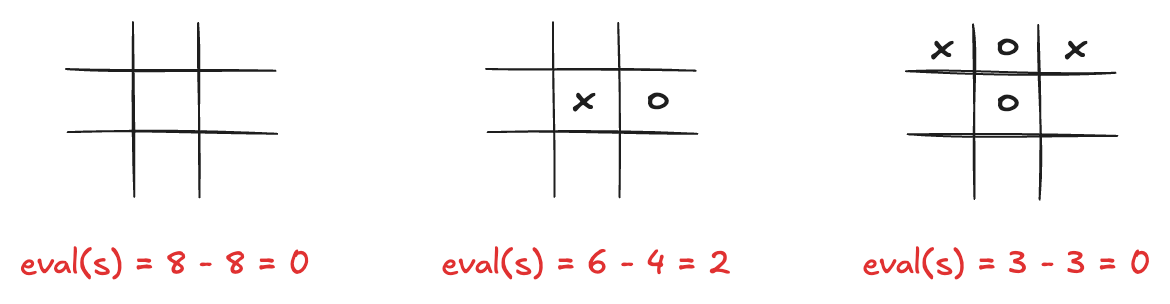


In [50]:
def eval_tictactoe(board, MAX='X', MIN='O'):

    # Convert the state's board (tuple of (position, value) pairs) 
    # into a dictionary
    board_dict = dict(board)

    # Build a 3x3 numpy array from the dictionary. 
    # Default to '.' if a cell is not present.
    board = np.array([[board_dict.get((i, j), '.') for j in range(3)] for i in range(3)])
    
    def count_open_lines(board, player):

        count = 0
        
        # Check rows
        for row in board:
            if np.all((row == player) | (row == '.')):
                count += 1
        
        # Check columns
        for col in board.T:
            if np.all((col == player) | (col == '.')):
                count += 1
        
        # Check diagonals
        diag1 = np.array([board[i, i] for i in range(3)])
        diag2 = np.array([board[i, 2 - i] for i in range(3)])
        if np.all((diag1 == player) | (diag1 == '.')):
            count += 1
        if np.all((diag2 == player) | (diag2 == '.')):
            count += 1
        
        return count

    return count_open_lines(board, MAX) - count_open_lines(board, MIN)

In [53]:
board_1 = {
    (0, 0): '.', (0, 1): '.', (0, 2): '.',
    (1, 0): '.', (1, 1): '.', (1, 2): '.',
    (2, 0): '.', (2, 1): '.', (2, 2): '.'
}

board_2 = {
    (0, 0): '.', (0, 1): '.', (0, 2): '.',
    (1, 0): '.', (1, 1): 'X', (1, 2): 'O',
    (2, 0): '.', (2, 1): '.', (2, 2): '.'
}

board_3 = {
    (0, 0): 'X', (0, 1): 'O', (0, 2): 'X',
    (1, 0): '.', (1, 1): 'O', (1, 2): '.',
    (2, 0): '.', (2, 1): '.', (2, 2): '.'
}

print(f"Evaluation score board 1: ", eval_tictactoe(board_1))
print(f"Evaluation score board 2: ", eval_tictactoe(board_2))
print(f"Evaluation score board 3: ", eval_tictactoe(board_3))

Evaluation score board 1:  0
Evaluation score board 2:  2
Evaluation score board 3:  0


Features and weights are derived from **domain knowledge**, not the game’s rules. In games lacking expert insight, machine learning can estimate evaluation weights. Applied to chess, this approach has validated traditional heuristics, showing that centuries of human expertise can be replicated in hours.

### Cutting off search

The evaluation function is **inherently imperfect**. However, as we go deeper into the tree, the importance of its precision diminishes, as we approach states closer to terminal states, where evaluating the situation becomes easier even with simple heuristics. This creates a tradeoff between the complexity of the heuristic and the depth at which to apply it. To address this, Minimax should be modified to call the heuristic function when it's appropriate to cut off the search. A simple approach to controlling the search depth is to set a **fixed depth limit**. Here's an example from Tic-Tac-Toe with a depth limit of 2:

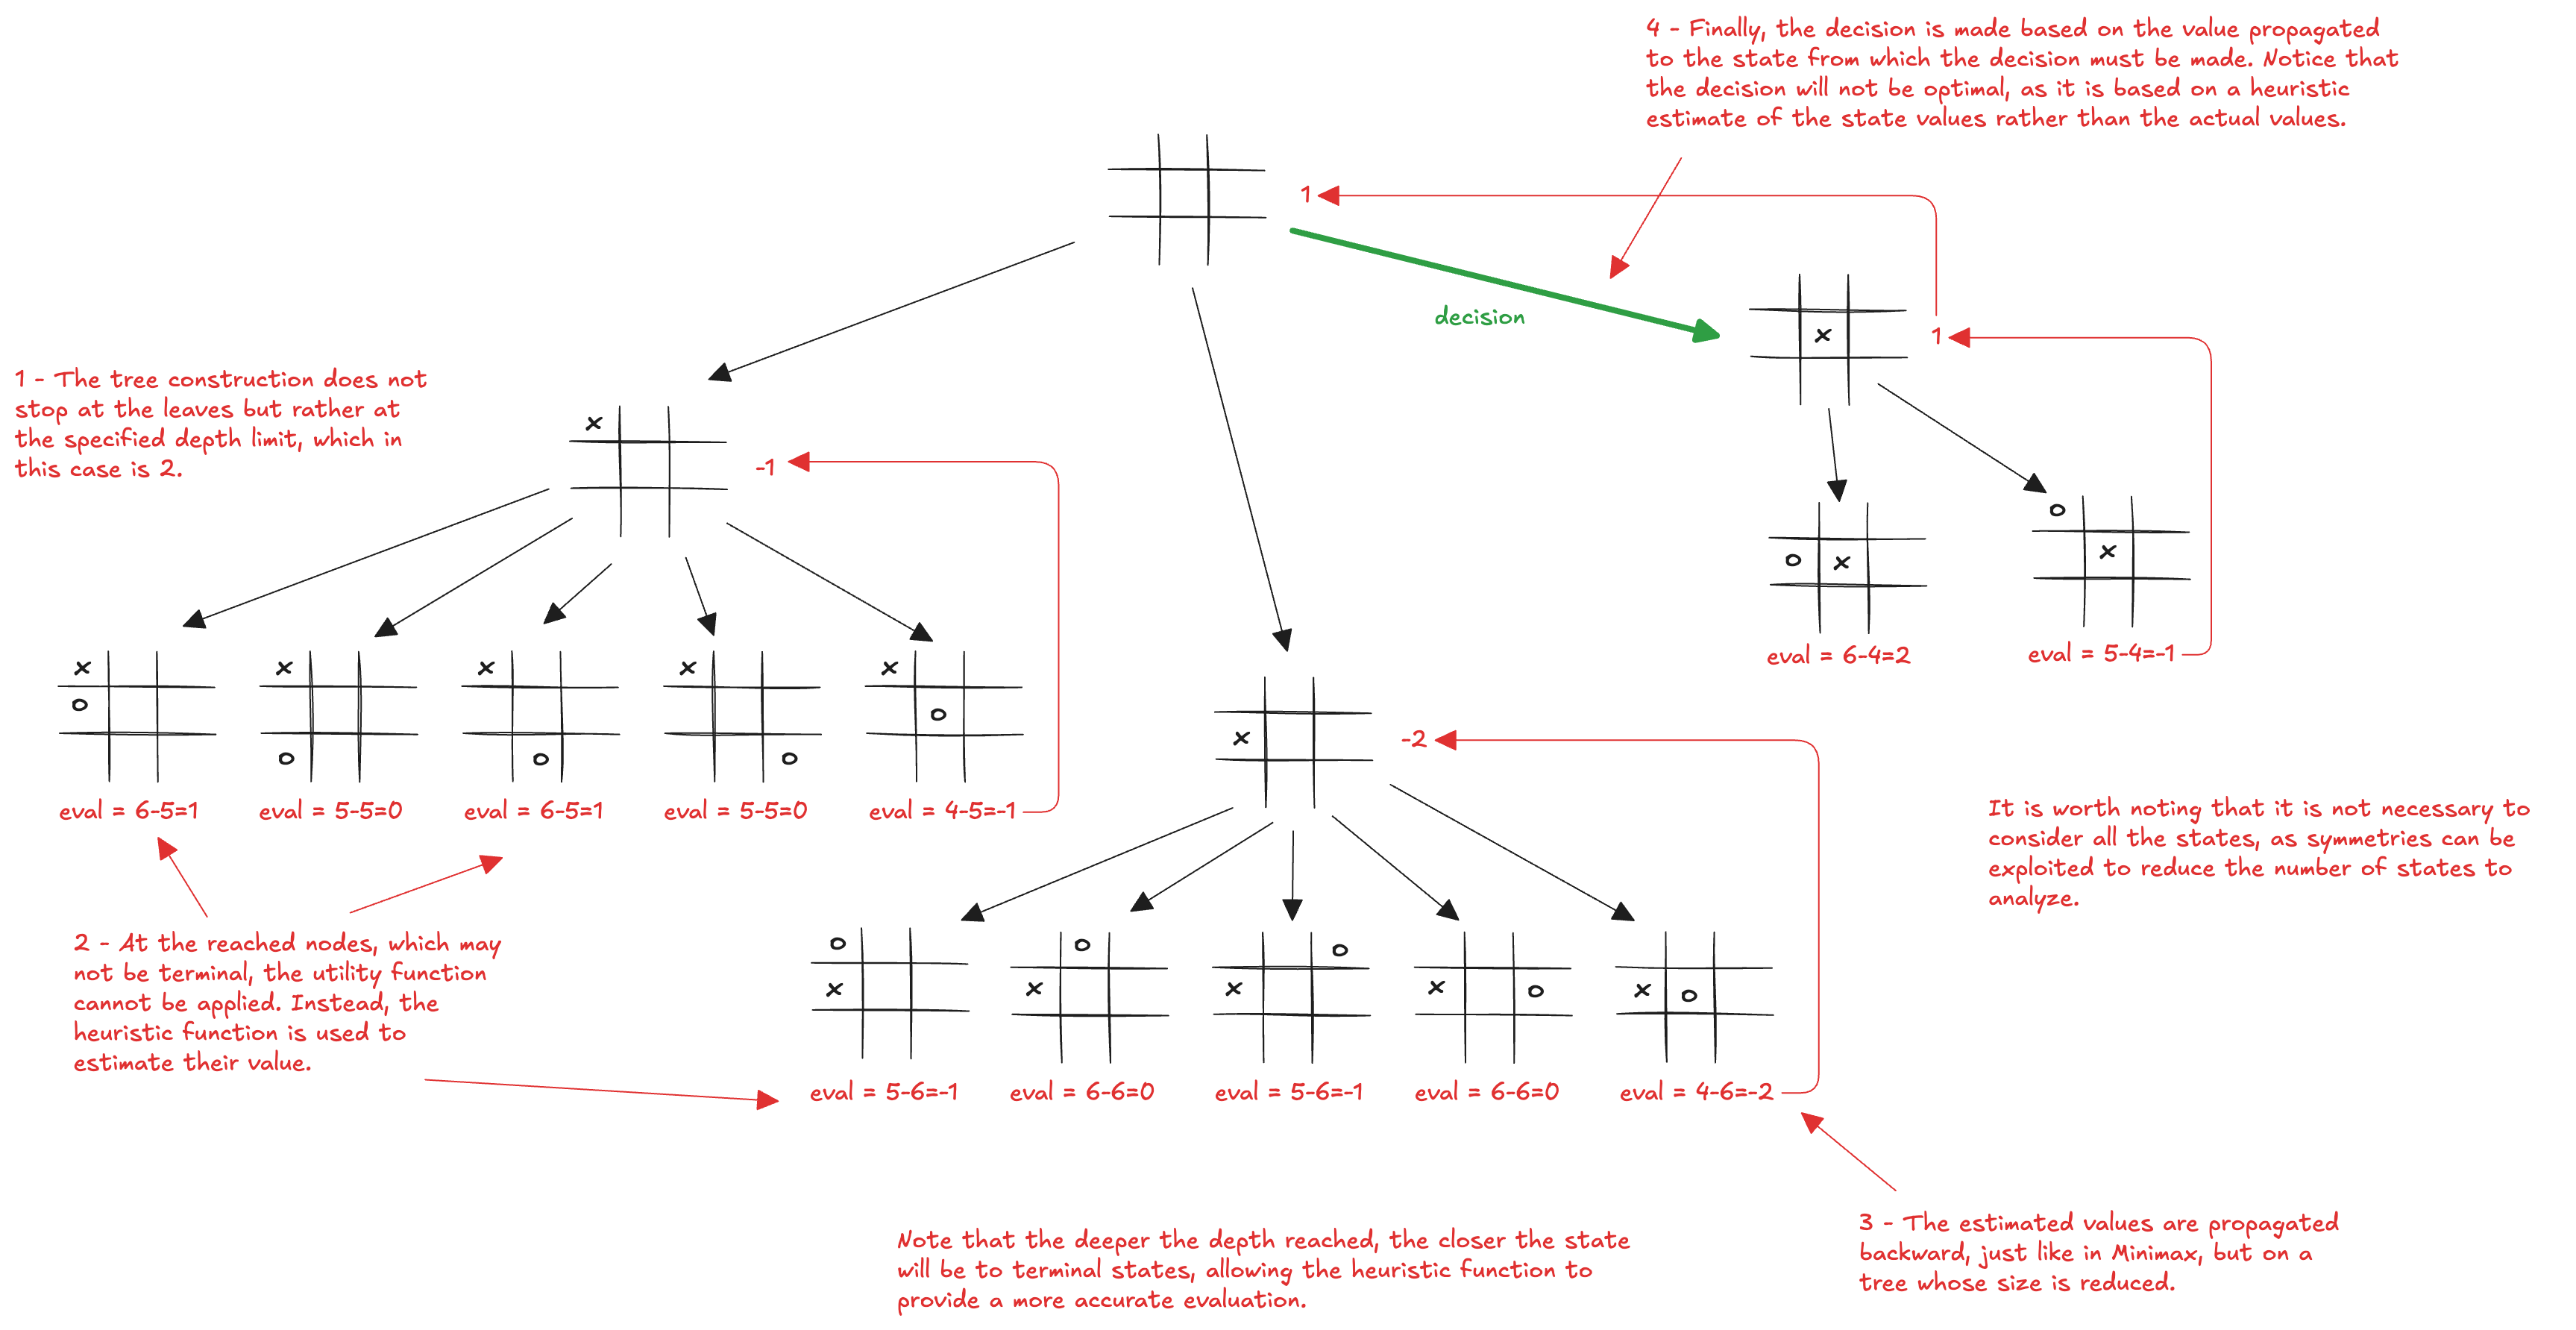

In [ ]:
def cutoff_player(game, state, eval=eval_tictactoe, max_depth=2, MAX='X', MIN='O'):

    player = state.to_move

    def max_value(state, depth):
        if game.terminal_test(state):
            return game.utility(state, game.to_move(game.initial)) 

        # If the maximum depth is reached, 
        # return the heuristic evaluation of the state
        if depth == 0:
            return eval(state.board)

        v = -float('inf')
        for action in game.actions(state):
            v = max(v, min_value(game.result(state, action), depth - 1))
        return v

    def min_value(state, depth):
        if game.terminal_test(state):
            return game.utility(state, game.to_move(game.initial))
        
        # If the maximum depth is reached, 
        # return the heuristic evaluation of the state
        if depth == 0: 
            return eval(state.board)

        v = float('inf')
        for action in game.actions(state):
            v = min(v, max_value(game.result(state, action), depth - 1))
        return v

    best_action = None
    if player == MAX:
        best_value = -float('inf')
        for action in game.actions(state):
            value = min_value(game.result(state, action), max_depth - 1)
            if value > best_value:
                best_value = value
                best_action = action
    else:
        best_value = float('inf')
        for action in game.actions(state):
            value = max_value(game.result(state, action), max_depth - 1)
            if value < best_value:
                best_value = value
                best_action = action

    return best_action

We can run the experiment with the heuristic minimax algorithm and a depth limit of 2:

In [54]:
# Create a new TicTacToe game
tictactoe = TicTacToe(h=3, v=3, k=3)

# Run the experiment
win_max_prop, win_min_prop, draw_prop = run_experiment(tictactoe, cutoff_player, random_player, num_games=100)

# Print the results:
print(f"Proportion of Wins for MAX Minimax player: {win_max_prop:.4f}")
print(f"Proportion of Wins for MIN Random player: {win_min_prop:.4f}")
print(f"Proportion of Draws: {draw_prop:.4f}")

Proportion of Wins for MAX Minimax player: 0.8600
Proportion of Wins for MIN Random player: 0.0300
Proportion of Draws: 0.1100


We can see that the obtained player is not optimal (sometimes it loses), but it is much faster than the optimal one since it should not explore the entire game tree. The depth limit is a **trade-off** between **speed** and **accuracy**. A more robust approach is to returns the move selected by the deepest completed search **when time runs out**. 

These simple approaches can **lead to errors due to the approximate nature of the evaluation function**. For example, a chess evaluation function based on material advantage might misjudge a position if it ignores imminent threats. Suppose the search stops at a depth limit where Black leads by a knight and two pawns, it may evaluate the position as winning for Black. However, if White's next move captures Black’s queen, the true advantage shifts dramatically. To avoid such errors, evaluation should apply only to **quiescent** positions—those without immediate, drastic changes like major captures. For **non-quiescent** positions, the search should continue until stability is reached. This **quiescence search** often focuses on specific moves, such as captures, to resolve uncertainties efficiently.

## Stochastic Games

Stochastic games bring us a little closer to the unpredictability of real life by including a
random element, such as the throwing of dice. Backgammon is a typical stochastic game that
combines luck and skill. In the backgammon position of Figure 5.12, White has rolled a 6–5
and has four possible moves (each of which moves one piece forward (clockwise) 5 positions,
and one piece forward 6 positions).
